In [1]:
import sys
sys.path.append('../')
import karman
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
device = 'cpu'
torch_type = 'float32'
batch_size = 1024
num_workers = 64
normalization_dict_path = None
model_path = None
run_name = ''
thermo_path = '/shared/us-hl-therm-landing/satellites_data_w_sw_2mln.csv'
min_date = '2000-07-29 00:59:47'
max_date = '2024-05-31 23:59:32'
omni_indices_path = '/shared/us-hl-therm-landing/omniweb_data/merged_omni_indices.csv'
omni_magnetic_field_path = '/shared/us-hl-therm-landing/omniweb_data/merged_omni_magnetic_field.csv'
omni_solar_wind_path = '/shared/us-hl-therm-landing/omniweb_data/merged_omni_solar_wind.csv'
nrlmsise00_path = '/shared/us-hl-therm-landing/nrlmsise00_data/nrlmsise00_time_series.csv'
goes_path = None
soho_path = '/shared/us-hl-therm-landing/soho_data/soho_data.csv'
lag_minutes = 0
resolution_minutes = 10
features_to_exclude_thermo = []

In [3]:
karman_dataset = karman.KarmanDataset(
    thermo_path=thermo_path,
    min_date=pd.to_datetime(min_date),
    max_date=pd.to_datetime(max_date),
    normalization_dict=None,
    nrlmsise00_path=nrlmsise00_path,
    omni_indices_path=omni_indices_path,
    omni_magnetic_field_path=omni_magnetic_field_path,
    omni_solar_wind_path=omni_solar_wind_path,
    soho_path=soho_path,
    lag_minutes_nrlmsise00=lag_minutes,
    nrlmsise00_resolution=resolution_minutes,
    lag_minutes_omni=lag_minutes,
    omni_resolution=resolution_minutes,
    lag_minutes_soho=lag_minutes,
    soho_resolution=resolution_minutes,
    # features_to_exclude_thermo=features_to_exclude_thermo
)

Loading Omni indices.


/home/jordivilaperez/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/jordivilaperez/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Loading Omni Solar Wind.


/home/jordivilaperez/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/jordivilaperez/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Loading Omni Magnetic Field.


...

Creating thermospheric density dataset
Removing from the data errors in mean absolute percentage error 200% or more in the density (between nrlmsise00 and ground truth)
loading it from file
passed mask in exclude_mask.pk does not exist or not valid, computing it


100%|██████████| 132/132 [00:01<00:00, 107.19it/s]


saving it to pickle file: exclude_mask.pk
Used features: Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'celestrack__ap_average__',
       'space_environment_technologies__f107_obs__',
       'space_environment_technologies__f107_average__',
       'space_environment_technologies__s107_obs__',
       'space_environment_technologies__s107_average__',
       'space_environment_technologies__m107_obs__',
       'space_environment_technologies__m107_average__',
       'space_environment_technologies__y107_obs__',
       'space_environment_technologies__y107_average__', 'JB08__d_st_dt__[K]',
       'tudelft_thermo__longitude__[deg]_sin',
       'tudelft_thermo__longitude__[deg]_cos', 'all__day_of_year__[d]_sin',
       'all__day_of_year__[d]_cos', 'all__seconds_in_day__[s]_sin',
       'all__seconds_in_day__[s]_cos'],
      dtype='object')
Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'celestrack__ap_average__',
       '

/home/jordivilaperez/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:496: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())



Finished Creating dataset.


In [4]:
#Train, validation, test splits:
idx_test_fold=2
test_month_idx = 2 * (idx_test_fold - 1)
validation_month_idx = test_month_idx + 2
print(test_month_idx,validation_month_idx)
karman_dataset._set_indices(test_month_idx=[test_month_idx], validation_month_idx=[validation_month_idx],custom={
    2001: {"validation":2,"test":3},
    2003: {"validation":9, "test":10},
    2005: {"validation":4, "test":5},
    2012: {"validation":8, "test":9},
    2013: {"validation":4, "test":5},
    2015: {"validation":2, "test":3},
    2022: {"validation":0, "test":1},
    2024: {"validation":3,"test":4}}
)
train_dataset = karman_dataset.train_dataset()
validation_dataset = karman_dataset.validation_dataset()
test_dataset = karman_dataset.test_dataset()

train_minibatch = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        num_workers=num_workers
)

validation_minibatch = torch.utils.data.DataLoader(
        validation_dataset,
        batch_size=batch_size,
        num_workers=num_workers
)

test_minibatch = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        num_workers=num_workers
)

2 4
Creating training, validation and test sets.


25 years to iterate through.: 100%|██████████| 25/25 [00:03<00:00,  6.86it/s]

Train size: 1641897
Validation size: 162991
Test size: 175278


In [5]:
altitude_bins_classification = {'0-200 km': 0,
                                '200-250 km': 1,
                                '250-300 km': 2,
                                '300-350 km': 3,
                                '350-400 km': 4,
                                '400-450 km': 5,
                                '450-500 km': 6,
                                '500-550 km': 7,
                                '550-600 km': 8}

solar_activity_bins_classification = {'F10.7: 0-70 (low)': 0,
                                      'F10.7: 70-150 (moderate)': 1,
                                      'F10.7: 150-200 (moderate-high)': 2,
                                      'F10.7: 200 (high)': 3}

storm_types = {
    "G0": 0,
    "G1": 1,
    "G2": 2,
    "G3": 3,
    "G4": 4,
    "G5": 5,
}

In [6]:
def flatten_instance(instance):
    flat_dict = {}
    for key, value in instance.items():
        if isinstance(value, torch.Tensor):
            if value.dim() == 0:  # scalar tensor
                flat_dict[key] = value.item()
            elif value.dim() == 1:  # vector tensor
                for i, val in enumerate(value):
                    flat_dict[f'{key}_{i}'] = val.item()
            elif value.dim() == 2:  # 2D tensor
                for i, row in enumerate(value):
                    for j, val in enumerate(row):
                        flat_dict[f'{key}_{i}_{j}'] = val.item()
        else:
            flat_dict[key] = value
    return flat_dict

In [7]:
def array_from_dataset(dataset_batches, num_samples, num_columns):
    exclude = ["date"]
    dataset_array = np.zeros((num_samples,num_columns))
    idx_dataset = 0
    for batch_idx,el in enumerate(dataset_batches):
        idx_feature = 0
        size_batch = len(el['date'])
        array_batch = np.zeros((size_batch,num_columns))
        
        for k,v in el.items():
            if k in exclude:
                continue 

            num_features = int(np.size(np.array(v))/np.size(np.array(v),0))

            match k:
                case 'geomagnetic_storm_G_class':
                    aux = np.zeros((size_batch,1))
                    for ielem in range(len(v)):
                        aux[ielem] = storm_types[v[ielem]]
                    array_batch[:,idx_feature:idx_feature+num_features] = aux
                case 'altitude_bins': 
                    aux = np.zeros((size_batch,1))
                    for ielem in range(len(v)):
                        aux[ielem] = altitude_bins_classification[v[ielem]]
                    array_batch[:,idx_feature:idx_feature+num_features] = aux
                case 'solar_activity_bins':
                    aux = np.zeros((size_batch,1))
                    for ielem in range(len(v)):
                        aux[ielem] = solar_activity_bins_classification[v[ielem]]
                    array_batch[:,idx_feature:idx_feature+num_features] = aux
                case _:
                    array_batch[:,idx_feature:idx_feature+num_features] = np.array(v).reshape(size_batch,num_features)

            idx_feature += num_features

        dataset_array[idx_dataset:idx_dataset+size_batch,:] = array_batch
        idx_dataset += size_batch

    return dataset_array


In [31]:
keylist = [key for key in flatten_instance(karman_dataset[0])]
keylist[0:18] = karman_dataset.column_names_instantaneous_features
keylist.remove('date')

In [8]:
num_columns = len(flatten_instance(karman_dataset[0]))-1

num_test = len(test_dataset)
num_validation = len(validation_dataset)
num_train = len(train_dataset)

In [22]:
test_array = array_from_dataset(test_minibatch, num_test, num_columns)

In [23]:
test_mean = np.mean(test_array,axis=0)
test_var = np.var(test_array,axis=0)

array([[<Axes: title={'center': 'tudelft_thermo__altitude__[m]'}>,
        <Axes: title={'center': 'tudelft_thermo__latitude__[deg]'}>,
        <Axes: title={'center': 'celestrack__ap_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_average__'}>],
       [<Axes: title={'center': 'space_environment_technologies__m107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__m107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__y107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__y107_average__'}>,
        <Axes: title={'center': 'JB08__d_st_dt__[K]'}>,
        <Axes: title={'center': 'tudelft_thermo__longitude__[deg]_sin'}>,
        <Axes: 

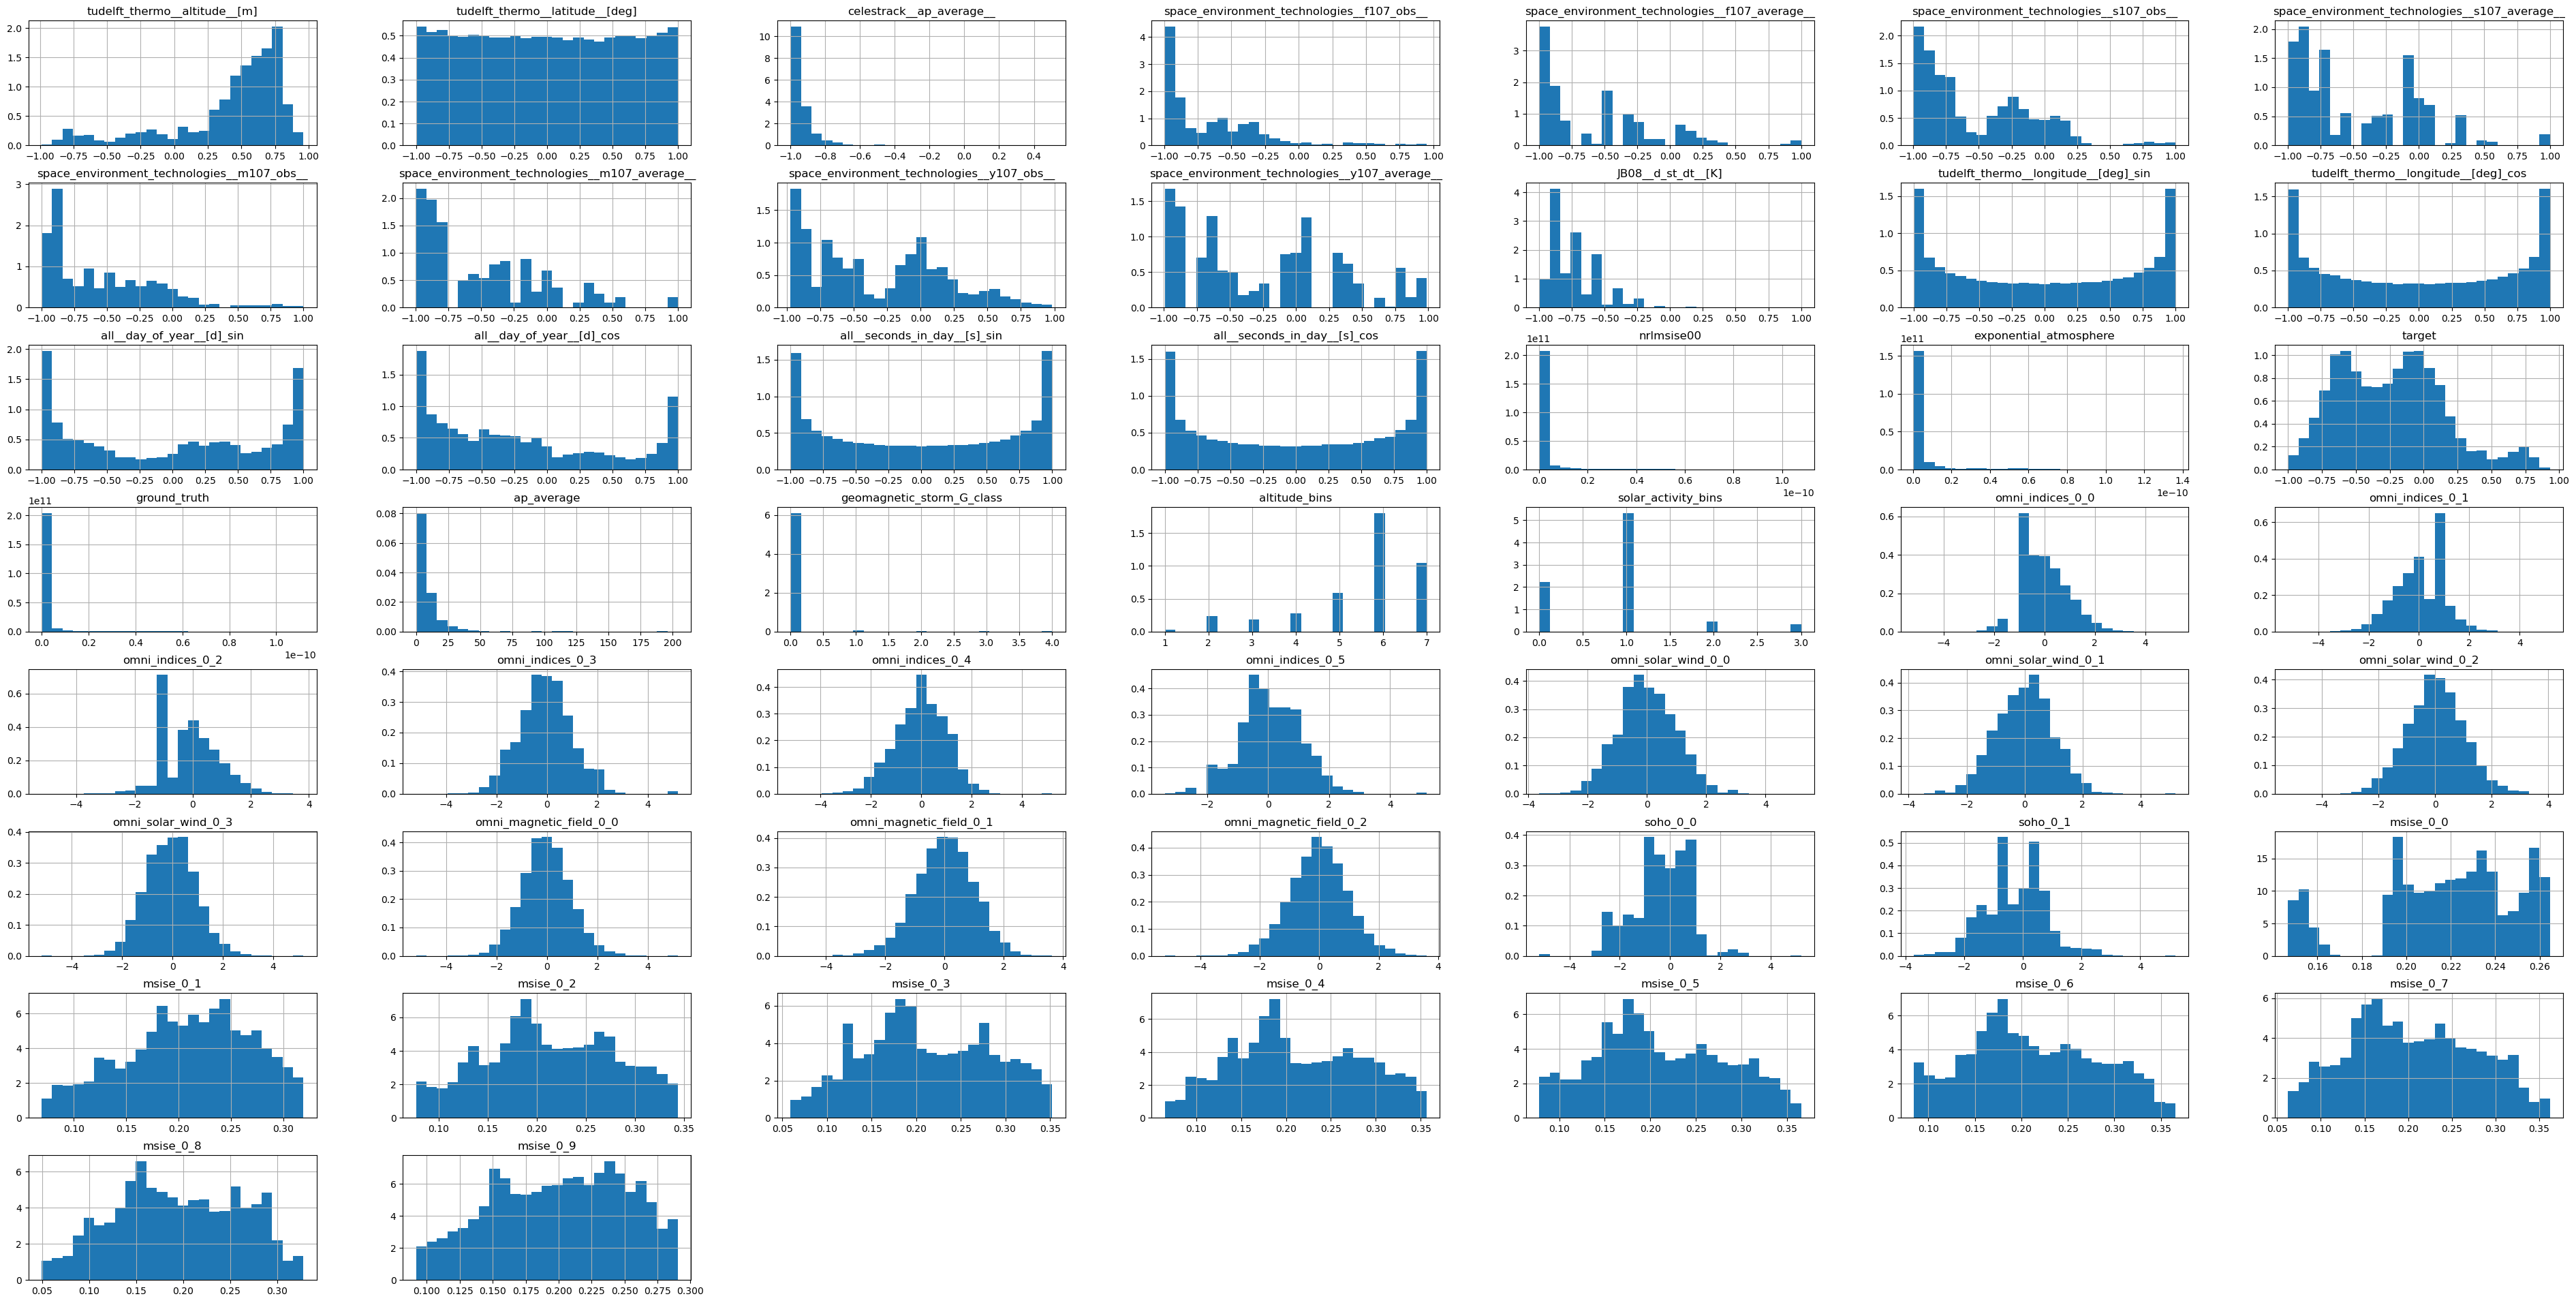

In [43]:
test_df = pd.DataFrame(test_array,columns=keylist)
test_df.hist(figsize=(48,24),bins=25,density=True)

In [35]:
validation_array = array_from_dataset(validation_minibatch, num_validation, num_columns)

In [36]:
validation_mean = np.mean(validation_array,axis=0)
validation_var = np.var(validation_array,axis=0)

array([[<Axes: title={'center': 'tudelft_thermo__altitude__[m]'}>,
        <Axes: title={'center': 'tudelft_thermo__latitude__[deg]'}>,
        <Axes: title={'center': 'celestrack__ap_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_average__'}>],
       [<Axes: title={'center': 'space_environment_technologies__m107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__m107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__y107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__y107_average__'}>,
        <Axes: title={'center': 'JB08__d_st_dt__[K]'}>,
        <Axes: title={'center': 'tudelft_thermo__longitude__[deg]_sin'}>,
        <Axes: 

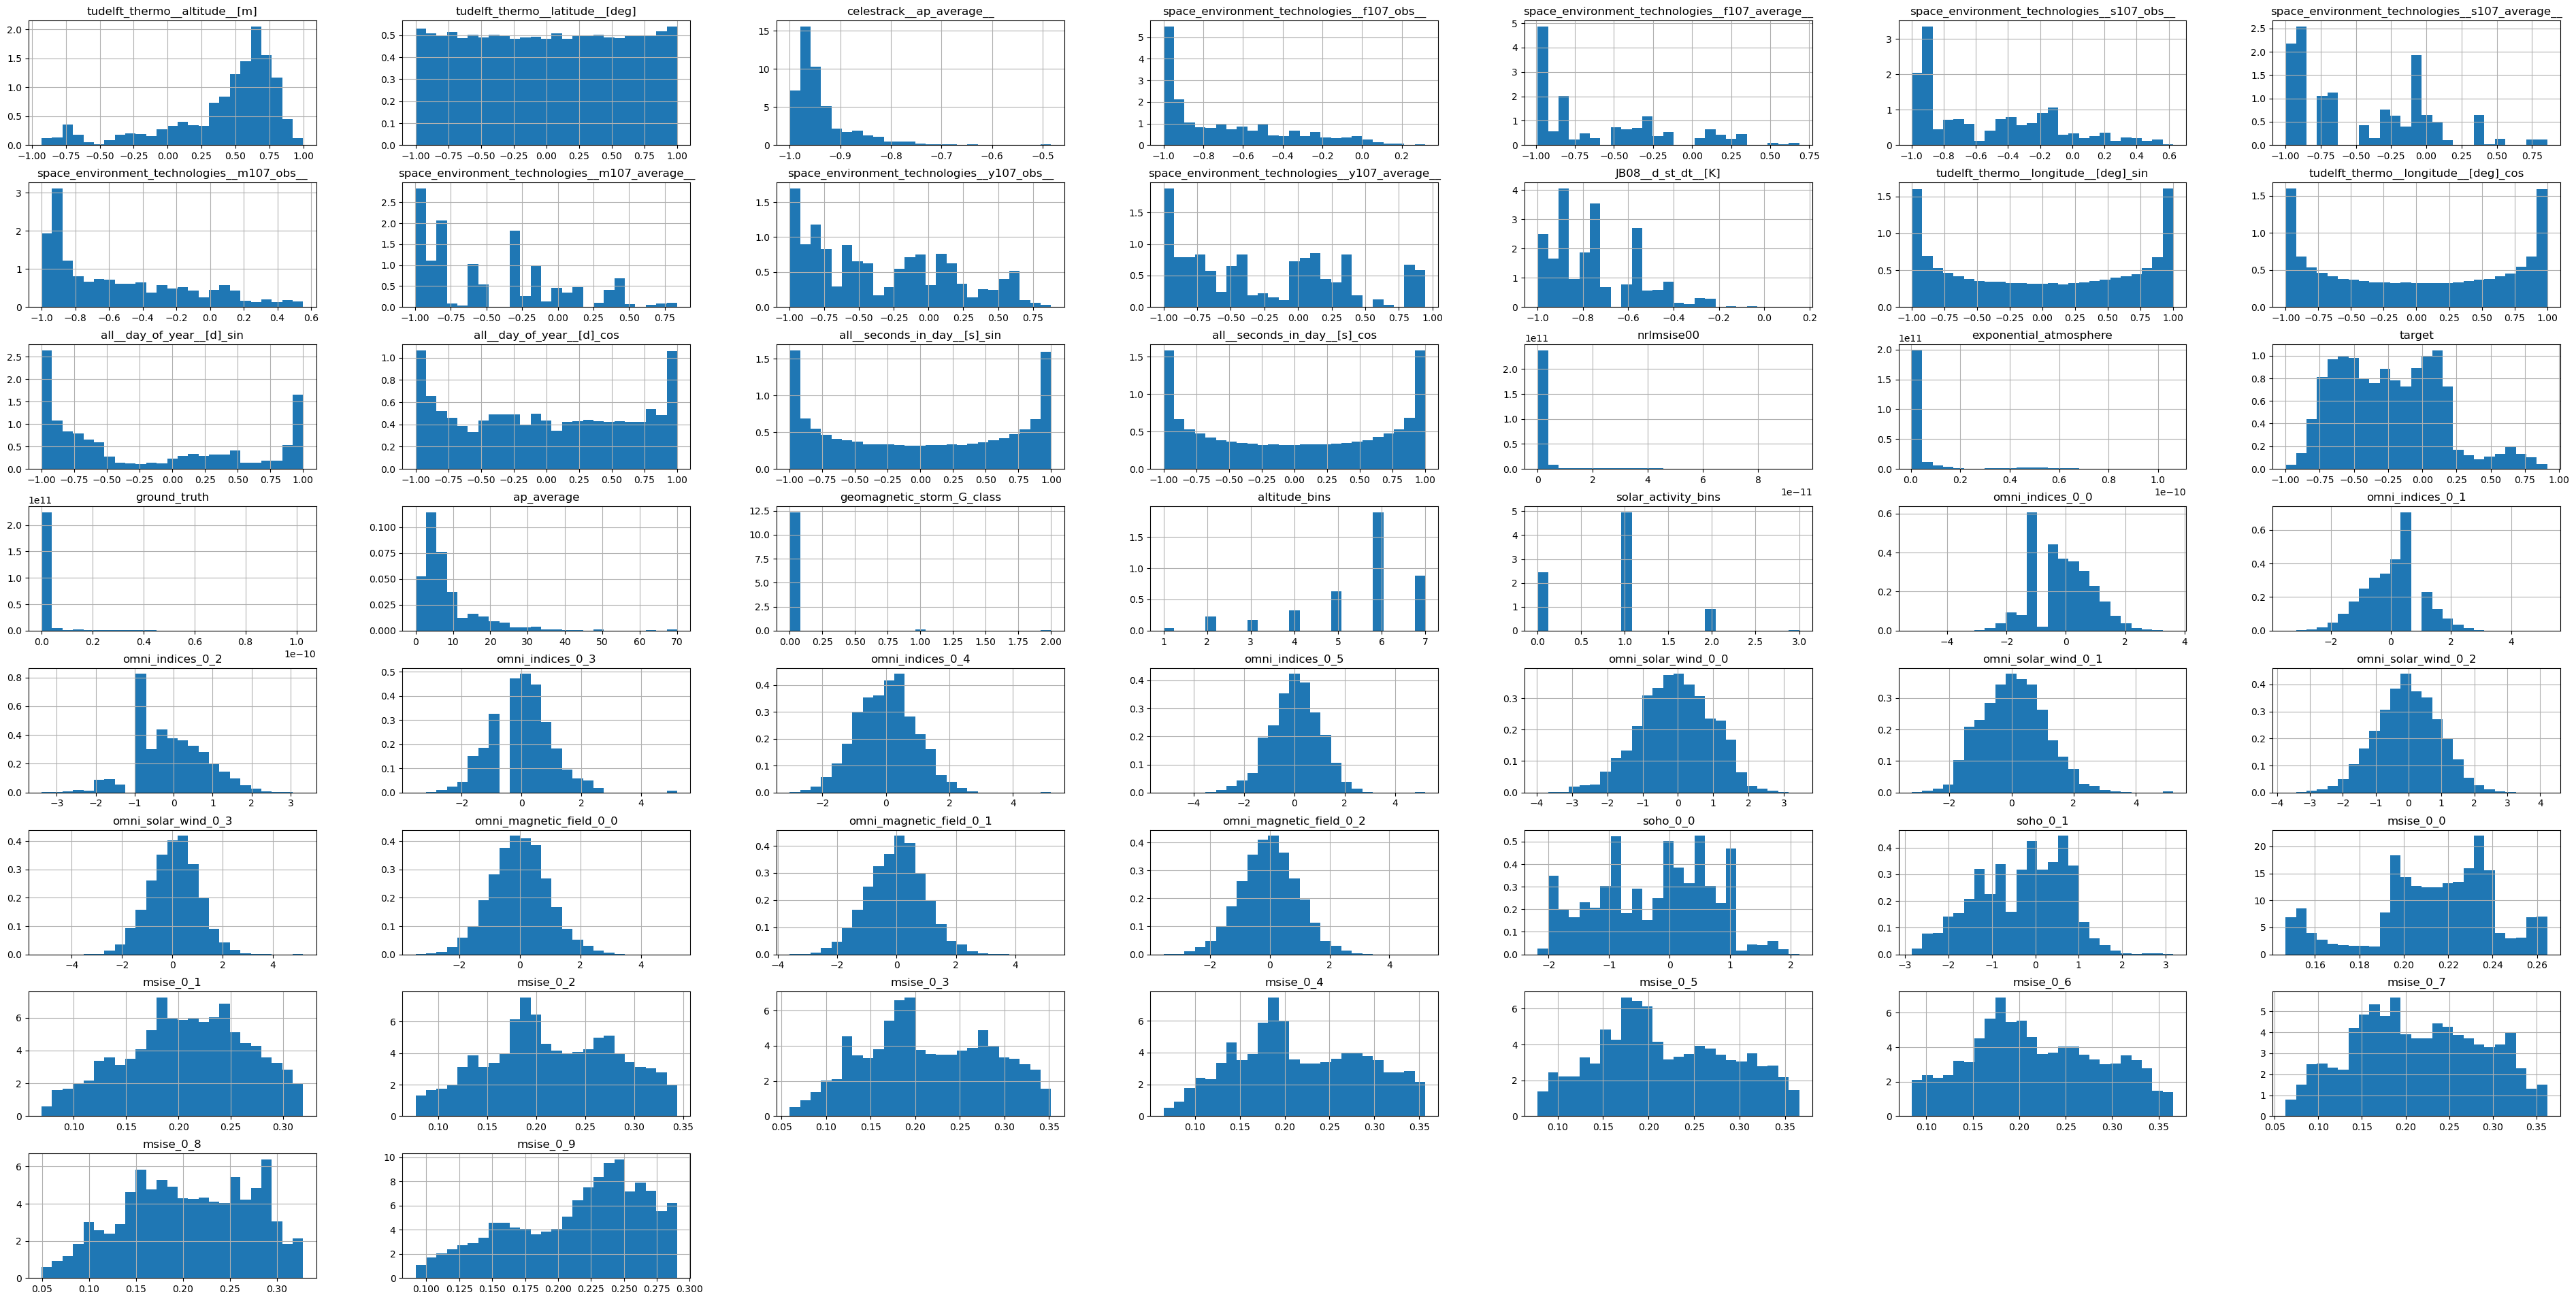

In [42]:
validation_df = pd.DataFrame(validation_array,columns=keylist)
validation_df.hist(figsize=(48,24),bins=25,density=True)

In [38]:
train_array = array_from_dataset(train_minibatch, num_train, num_columns)

In [39]:
train_mean = np.mean(train_array,axis=0)
train_var = np.var(train_array,axis=0)

array([[<Axes: title={'center': 'tudelft_thermo__altitude__[m]'}>,
        <Axes: title={'center': 'tudelft_thermo__latitude__[deg]'}>,
        <Axes: title={'center': 'celestrack__ap_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_average__'}>],
       [<Axes: title={'center': 'space_environment_technologies__m107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__m107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__y107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__y107_average__'}>,
        <Axes: title={'center': 'JB08__d_st_dt__[K]'}>,
        <Axes: title={'center': 'tudelft_thermo__longitude__[deg]_sin'}>,
        <Axes: 

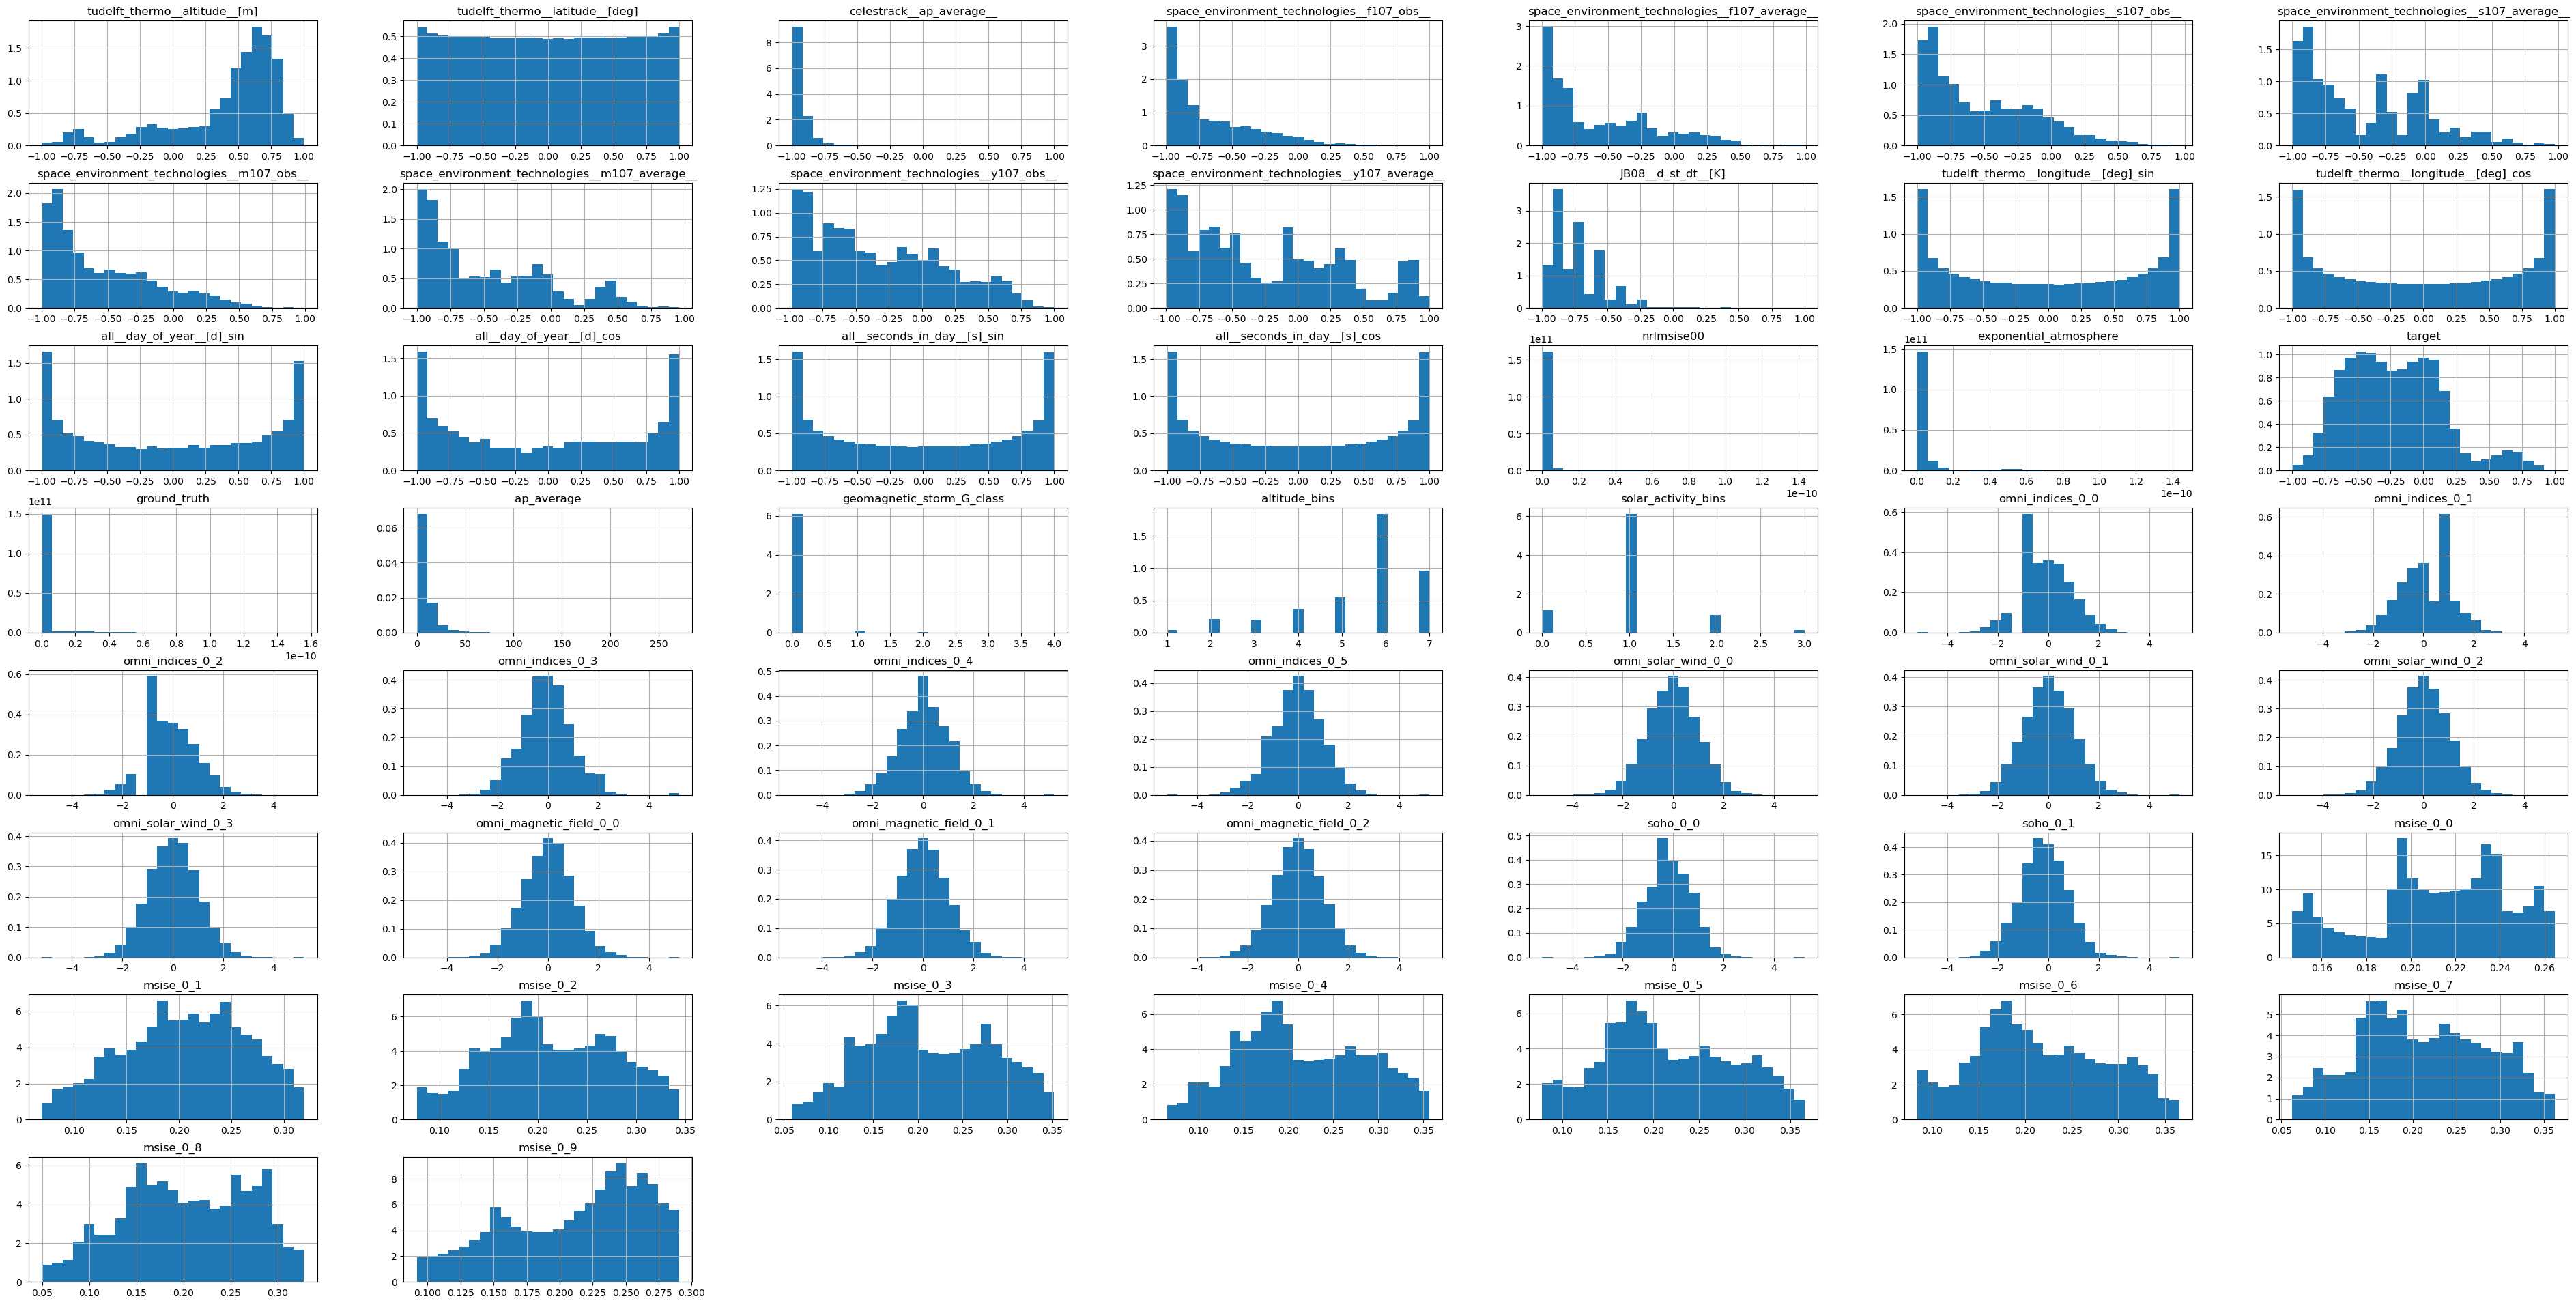

In [41]:
train_df = pd.DataFrame(train_array,columns=keylist)
train_df.hist(figsize=(48,24),bins=25, density=True)

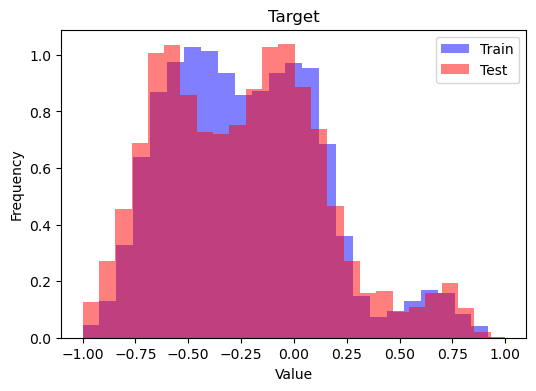

In [65]:
plt.figure(figsize=(6, 4))

plt.hist(train_df['target'], bins=25, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(test_df['target'], bins=25, alpha=0.5, density=True, label='Test', color='red')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Target')
plt.legend()

plt.show()

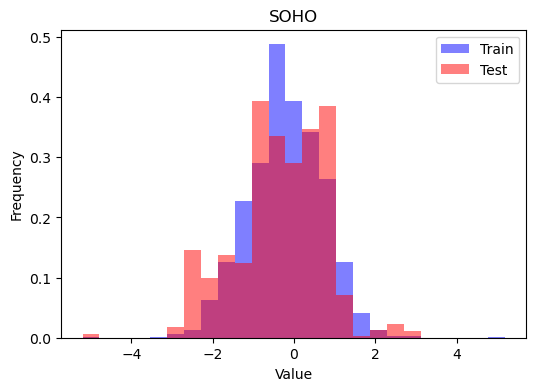

In [66]:
plt.figure(figsize=(6, 4))

plt.hist(train_df['soho_0_0'], bins=25, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(test_df['soho_0_0'], bins=25, alpha=0.5, density=True, label='Test', color='red')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('SOHO')
plt.legend()

plt.show()

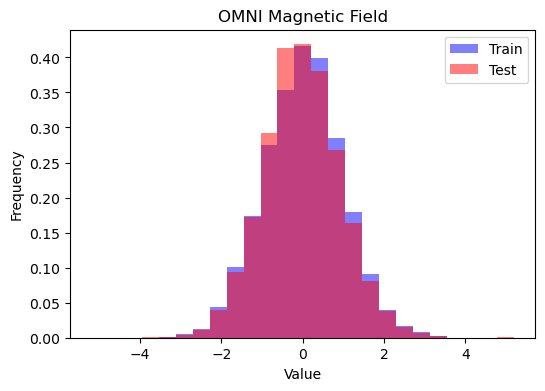

In [68]:
plt.figure(figsize=(6, 4))

plt.hist(train_df['omni_magnetic_field_0_0'], bins=25, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(test_df['omni_magnetic_field_0_0'], bins=25, alpha=0.5, density=True, label='Test', color='red')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('OMNI Magnetic Field')
plt.legend()

plt.show()

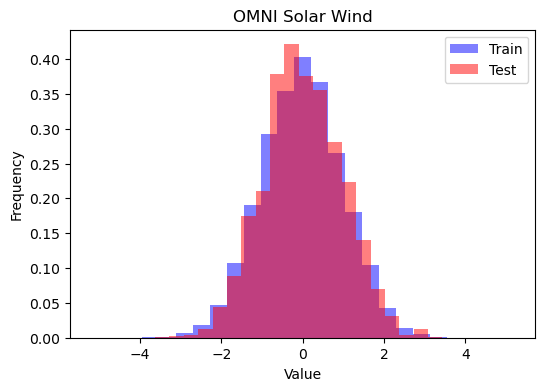

In [80]:
plt.figure(figsize=(6, 4))

plt.hist(train_df['omni_solar_wind_0_0'], bins=25, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(test_df['omni_solar_wind_0_0'], bins=25, alpha=0.5, density=True, label='Test', color='red')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('OMNI Solar Wind')
plt.legend()

plt.show()

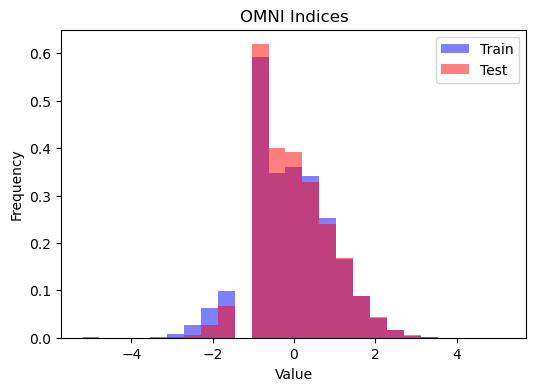

In [81]:
plt.figure(figsize=(6, 4))

plt.hist(train_df['omni_indices_0_0'], bins=25, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(test_df['omni_indices_0_0'], bins=25, alpha=0.5, density=True, label='Test', color='red')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('OMNI Indices')
plt.legend()

plt.show()

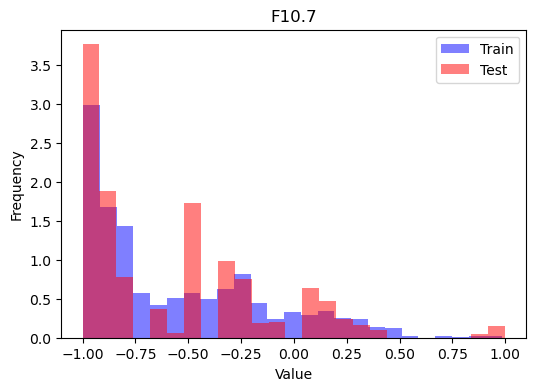

In [75]:
plt.figure(figsize=(6, 4))

plt.hist(train_df['space_environment_technologies__f107_average__'], bins=25, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(test_df['space_environment_technologies__f107_average__'], bins=25, alpha=0.5, density=True, label='Test', color='red')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('F10.7')
plt.legend()

plt.show()

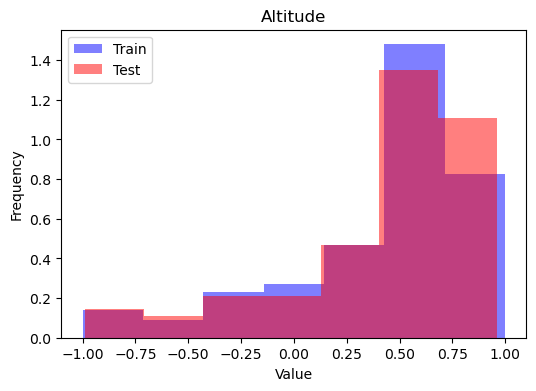

In [77]:
plt.figure(figsize=(6, 4))

plt.hist(train_df['tudelft_thermo__altitude__[m]'], bins=7, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(test_df['tudelft_thermo__altitude__[m]'], bins=7, alpha=0.5, density=True, label='Test', color='red')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Altitude')
plt.legend()

plt.show()